In [226]:
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns
import numpy as np
import statsmodels.api as sm
import os

Having processed and integrated the disparate data sources (USDA wholesale pricing, USDA meat supply and disappearance, and FRED macro indices) via the automated pipeline ('import_and_clean.py'), we load the unified dataset spanning the years 2000 to 2025.

Before conducting formal econometric modeling, we call df.describe() to evaluate the scale, variance, and distributional bounds of our market features.

In [227]:
df = pd.read_csv('data/processed/beef_market_clean_dataset.csv')
df.describe()

,year,choice_price,select_price,90%_fresh_price,90%_imported_frozen_price,commercial_production,farm_production,total_production,begin_stock,imports,total_supply,exports,end_stock,total_disappearance,population,carcass_weight,retail_weight,boneless_retail_weight,PPIACO
count,26.000000,26.000000,26.000000,26.000000,26.000000,26.000000,26.000000,26.000000,26.000000,26.000000,26.000000,26.000000,26.000000,26.000000,26.000000,26.000000,26.000000,26.000000,26.000000
mean,2012.500000,199.092665,187.799708,200.386977,192.497054,26208.538462,81.696154,26290.234615,620.828454,3157.791000,30068.854069,2403.287385,627.188265,27038.378423,313962.384615,86.390504,60.473369,57.795238,190.951219
std,7.648529,64.970675,61.803340,74.693163,66.745833,1071.958983,17.075046,1070.888569,71.520057,721.022789,1338.866222,762.002412,58.262336,1161.774818,18027.824893,6.197709,4.338403,4.146259,39.024155
min,2000.000000,114.417500,107.664200,102.770800,95.440000,23697.800000,62.600000,23760.400000,411.260800,2056.525000,27719.415000,460.314000,518.132000,24681.781000,282398.200000,77.181600,54.027100,51.634500,131.116700
25%,2006.250000,146.043525,135.862700,137.393150,132.715825,25925.800000,67.150000,26005.575000,586.548250,2958.407250,28992.744500,2267.786750,586.548250,26397.689500,299537.250000,81.879175,57.315450,54.777175,166.727075
50%,2012.500000,193.155850,183.073750,205.711650,202.699400,26216.650000,72.700000,26304.650000,630.163500,3055.027000,29956.143500,2537.615500,630.163500,27231.399500,315316.200000,84.319400,59.023600,56.409650,191.987500
75%,2018.750000,237.196050,228.696650,251.502725,233.067175,26943.425000,101.750000,27011.600000,658.621000,3362.373250,30997.306000,2927.855000,658.621000,27859.266750,329621.750000,93.184025,65.228800,62.340100,203.095800
max,2025.000000,359.147500,342.820000,394.938300,351.387100,28290.700000,111.000000,28358.300000,756.692000,5470.533000,32423.838000,3545.464000,756.692000,28986.323000,341944.900000,96.807100,67.765000,64.763900,264.481000


Calling df.info() validates the structural integrity of our final dataset. It confirms a completely populated, zero-null panel consisting of 26 annual observations across 19 features. Furthermore, it verifies that data types are properly aligned for econometric analysis: our temporal anchor (year) is cleanly cast as an integer, while all market indicators are stored as floats.

In [228]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 26 entries, 0 to 25
Data columns (total 19 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   year                       26 non-null     int64  
 1   choice_price               26 non-null     float64
 2   select_price               26 non-null     float64
 3   90%_fresh_price            26 non-null     float64
 4   90%_imported_frozen_price  26 non-null     float64
 5   commercial_production      26 non-null     float64
 6   farm_production            26 non-null     float64
 7   total_production           26 non-null     float64
 8   begin_stock                26 non-null     float64
 9   imports                    26 non-null     float64
 10  total_supply               26 non-null     float64
 11  exports                    26 non-null     float64
 12  end_stock                  26 non-null     float64
 13  total_disappearance        26 non-null     float64
 14  populat

While df.describe() reveals inconsistent variance across the four wholesale beef categories, a static summary obscures the underlying distribution and temporal patterns. The following box plots and time-series visualizations allow us to evaluate category-specific volatility and identify shared structural cycles across the 2000–2025 horizon

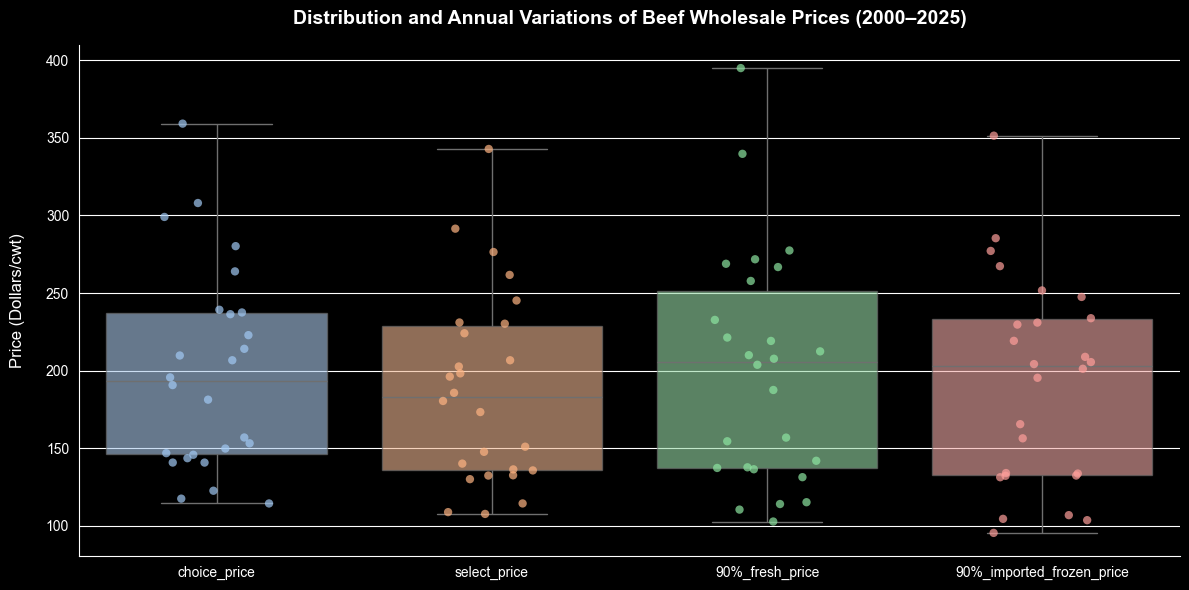

In [229]:
price_columns = [col for col in df.columns if 'price' in col]

plt.figure(figsize=(12, 6))

sns.boxplot(data=df[price_columns], palette='pastel', boxprops=dict(alpha=0.6))

sns.stripplot(data=df[price_columns], jitter=0.2, size=6, alpha=0.7, palette='pastel')

plt.title("Distribution and Annual Variations of Beef Wholesale Prices (2000–2025)", fontsize=14, pad=15, weight='semibold')
plt.ylabel("Price (Dollars/cwt)", fontsize=12, labelpad=15)
sns.despine()

plt.tight_layout()
plt.show()

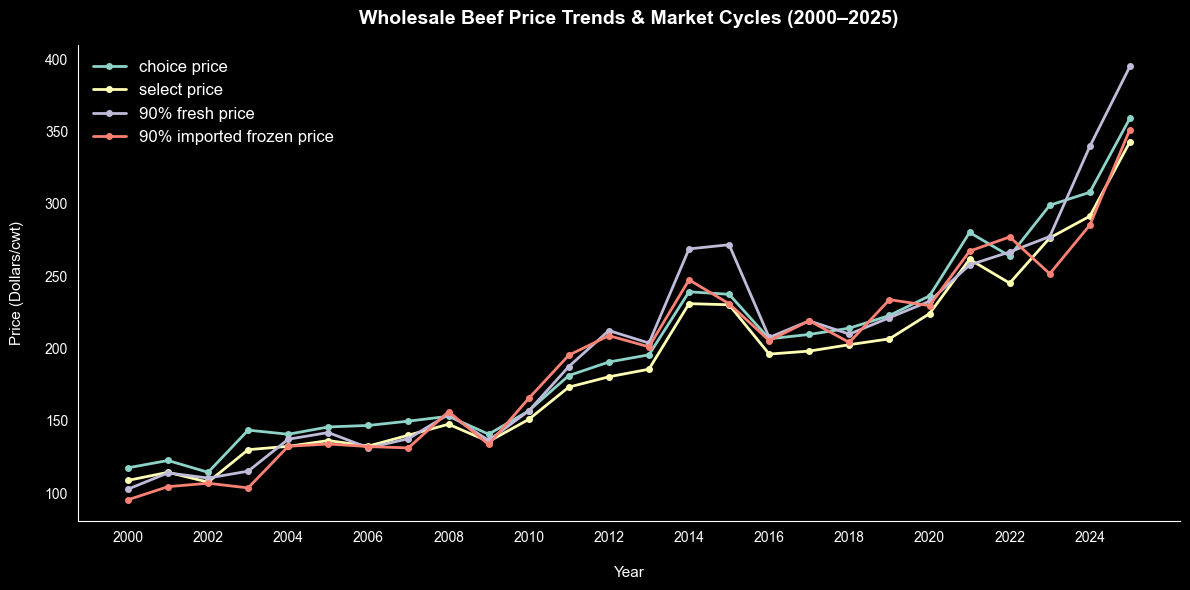

In [230]:
fig, ax = plt.subplots(figsize=(12, 6))

for col in price_columns:
    clean_label = col.replace('_', ' ')
    ax.plot(df['year'], df[col], label=clean_label, linewidth=2, marker='o', markersize=4)

ax.set_title(
    "Wholesale Beef Price Trends & Market Cycles (2000–2025)",
    fontsize=14,
    pad=15,
    weight="semibold",
)
ax.set_xlabel("Year", fontsize=11, labelpad=15)
ax.set_ylabel("Price (Dollars/cwt)", fontsize=11, labelpad=15)
ax.set_xticks(range(2000, 2026, 2))
ax.legend(loc="upper left", frameon=False, fontsize=12)

ax.grid(False)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

Visual and statistical diagnostics confirm that while all four wholesale categories share a highly synchronized macro trend, the 90%_fresh price exhibits the highest volatility. To establish a stable baseline for our structural analysis, we select the select_price series, which offers the most consistent variation over the 2000–2025 horizon. Before executing our regression models, we neutralize inflationary noise by deflating nominal prices into real 2025 dollars using the FRED Producer Price Index: All Commodities (PPIACO).

In [231]:
cur_cpi = df.loc[df['year'] == 2025]['PPIACO'].squeeze()
df['select_price_real_2025'] = df['select_price']*(cur_cpi/df['PPIACO'])

We next explore the scatter distributions of our target price against three vital supply-side pillars: imports, exports, and production. To maintain a focused explanatory framework, other contributing variables (e.g., beginning stocks, total disappearance) are omitted from this immediate scope. These elements, alongside latent variables like feedlot input costs and herd-rebuilding cycles, represent opportunities for future predictive modeling.

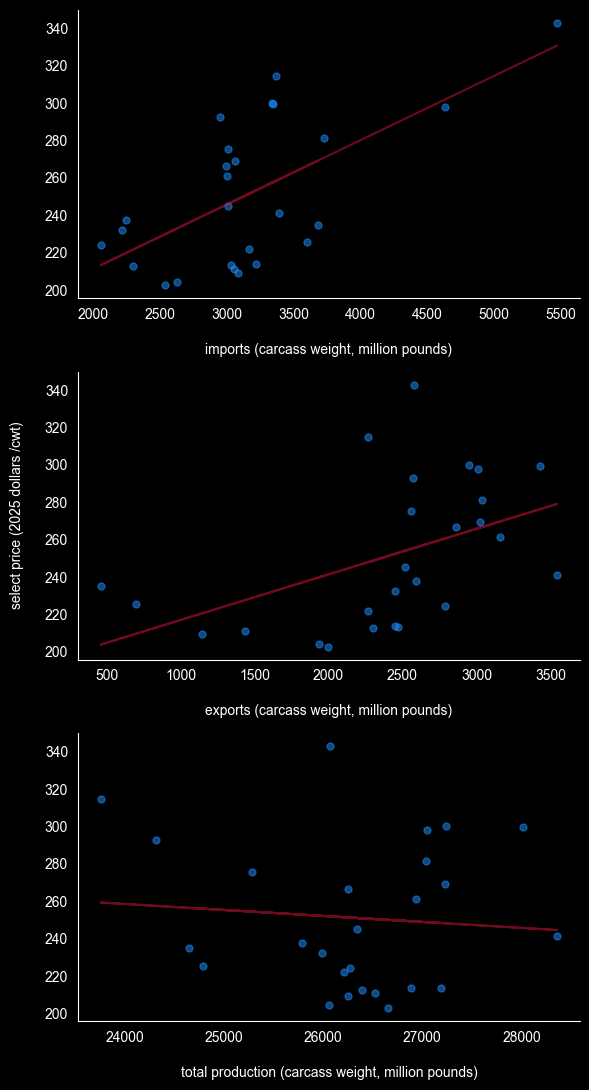

In [232]:
fig, axes = plt.subplots(3,1, figsize=(6, 11), sharey=True)

supply_vars = df[['imports', 'exports', 'total_production']]

for i, (col, ax) in enumerate(zip(supply_vars, axes)):
    cleaned_label = col.replace('_', ' ')

    ax.scatter(df[col], df['select_price_real_2025'], alpha=0.5, s=25, color='dodgerblue')

    m, b = np.polyfit(df[col], df['select_price_real_2025'], 1)
    ax.plot(df[col], m*df[col] + b, color='crimson', linewidth=1.5, alpha=0.5)

    ax.set_xlabel(f'{cleaned_label} (carcass weight, million pounds)', fontsize=10, labelpad=15)

    if i == 1:
        ax.set_ylabel('select price (2025 dollars /cwt)', fontsize=10, labelpad=15)

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(False)

plt.tight_layout()
plt.show()

Our initial exploratory analysis indicates that import volume has the strongest positive correlation with real select prices. While exports also show a positive trend, the relationship is noticeably more dispersed. Conversely, total production demonstrates a weak negative correlation. These diverging signals highlight the need for a multivariate regression to isolate the true marginal impact of each factor.

In [233]:
# feature engineering functions

def calc_per_capita(df, col, population):
    return df[col]/df[population]*1000

def calc_supply_share(df, col, total_supply):
    return df[col]/df[total_supply]*100

def calc_lag(df, col, lag):
    return df[col].shift(lag)

def calc_3yr_avg(df, col):
    return df[col].rolling(window=3).mean()

# matrix preparation

supply_vars = df[['imports', 'exports', 'total_production']]

mod_1 = supply_vars.copy()

mod_2 = pd.DataFrame(
    {
        f"{col}_per_capita": calc_per_capita(df, col, "population")
        for col in supply_vars.columns
    }
)
mod_3 = pd.DataFrame(
    {
        f"{col}_share": calc_supply_share(df, col, "total_supply")
        for col in supply_vars.columns
    }
)

mod_4 = pd.DataFrame(
    {f"{col}_lag1": calc_lag(df, col, 1) for col in supply_vars.columns}
)
mod_5 = pd.DataFrame(
    {f"{col}_lag2": calc_lag(df, col, 2) for col in supply_vars.columns}
)
mod_6 = pd.DataFrame(
    {f"{col}_lag3": calc_lag(df, col, 3) for col in supply_vars.columns}
)

mod_7 = pd.DataFrame(
    {f"{col}_3yr_avg": calc_3yr_avg(df, col) for col in supply_vars.columns}
)

In [234]:
# model engine and results extraction

def run_model(y, X):
    """Aligns target and features, drops NaNs, and fits a single OLS model."""
    # handle missing values from lag variables
    data = pd.concat([y, X], axis=1).dropna()
    y_clean = data['select_price_real_2025']
    x_clean = sm.add_constant(data[X.columns])
    model = sm.OLS(y_clean, x_clean).fit()
    coef_dict = dict(model.summary2().tables[1][['Coef.', 'Std.Err.', 't', 'P>|t|']])
    metrics_dict = {
        'R-squared': model.rsquared,
        'F-statistic': model.fvalue,
        'Prob (F-statistic)': model.f_pvalue,
        'Durbin-Watson': sm.stats.durbin_watson(model.resid),
        'AIC': model.aic,
        'BIC': model.bic
    }
    return coef_dict, metrics_dict

def get_results(y, X, model_name):
    """Executes the modeling engine, unpacks parameters, and generates a structured output DataFrame.
    """
    coef_dict, metrics_dict = run_model(y, X)

    coef_df = pd.DataFrame.from_dict(data=coef_dict)
    coef_idx = coef_df.index
    coef_df.insert(0, column='Predictor', value=coef_idx)

    coef_df.insert(0, column='Model', value=model_name)

    for metric_key, metric_value in metrics_dict.items():
        coef_df[metric_key] = metric_value

    coef_df.reset_index(drop=True, inplace=True)
    results = coef_df.round(4)

    return results

In [235]:
# pipeline execution

price = df['select_price_real_2025']

model_1_results = get_results(price, mod_1, 'Base Model')
model_2_results = get_results(price, mod_2, 'Per Capita')
model_3_results = get_results(price, mod_3, 'Share of Total Supply')
model_4_results = get_results(price, mod_4, 'Lag 1 Year')
model_5_results = get_results(price, mod_5, 'Lag 2 Years')
model_6_results = get_results(price, mod_6, 'Lag 3 Years')
model_7_results = get_results(price, mod_7, '3-Year Rolling Average')

final = pd.concat([model_1_results, model_2_results, model_3_results, model_4_results, model_5_results, model_6_results, model_7_results])

In [236]:
# experimental regression results

def save_results(results, file_path='data/results', file_name='experimental_results.csv'):
    os.makedirs(file_path, exist_ok=True)
    output_file = os.path.join(file_path, file_name)
    results.to_csv(output_file, index=False)
    print(f"Results saved to: {output_file}")

save_results(final)

Results saved to: data/results/experimental_results.csv


The experimental phase identifies the Per Capita Specification as our optimal model baseline. It maximizes variance explanation ($R^2$) while minimizing both AIC and BIC, confirming that its superior fit is not an artifact of over-parameterization. The joint significance of these per capita features is verified by an $F$-test $p$-value approaching zero.However, a Durbin-Watson statistic of 1.5358 indicates mild first-order residual autocorrelation—a common time-series vulnerability that can artificially deflate standard errors and distort significance tests. To address this diagnostic caveat and validate our statistical inferences, we transition to a dedicated validation and correction pipeline in supply_factors_per_capita_analysis.ipynb